In [1]:
#Flight Data Preprocessing

In [2]:
import shutil
import pandas as pd
import os
import missingno as msno
%matplotlib inline

In [3]:
years = ("2016", "2017")

#new directory and name for flight files
for year in years:
    for month in range(1, 12 + 1):
        source = f"Data/Flight Info/{year}/On_Time_On_Time_Performance_{year}_{month}/On_Time_On_Time_Performance_{year}_{month}.csv"
        dest = f"Data/FlightData/{year}_{month}.csv"
        os.makedirs(os.path.dirname(dest), exist_ok=True)
        new_path = shutil.copy(source, dest)
        print(new_path)

Data/FlightData/2016_1.csv
Data/FlightData/2016_2.csv
Data/FlightData/2016_3.csv
Data/FlightData/2016_4.csv
Data/FlightData/2016_5.csv
Data/FlightData/2016_6.csv
Data/FlightData/2016_7.csv
Data/FlightData/2016_8.csv
Data/FlightData/2016_9.csv
Data/FlightData/2016_10.csv
Data/FlightData/2016_11.csv
Data/FlightData/2016_12.csv
Data/FlightData/2017_1.csv
Data/FlightData/2017_2.csv
Data/FlightData/2017_3.csv
Data/FlightData/2017_4.csv
Data/FlightData/2017_5.csv
Data/FlightData/2017_6.csv
Data/FlightData/2017_7.csv
Data/FlightData/2017_8.csv
Data/FlightData/2017_9.csv
Data/FlightData/2017_10.csv
Data/FlightData/2017_11.csv
Data/FlightData/2017_12.csv


In [4]:
airports = ('ATL','CLT','DEN','DFW','EWR','IAH','JFK','LAS','LAX','MCO','MIA','ORD','PHX','SEA','SFO') #airport codes
columns = ("Year",
          "Quarter",
          "Month",
          "DayofMonth",
          "FlightDate",
          "OriginAirportID",
          "Origin",
          "DestAirportID",
          "Dest",
          "CRSDepTime",
          "DepTime",
          "DepDelayMinutes",
          "DepDel15",
          "CRSArrTime",
          "ArrTime",
          "ArrDelayMinutes",
          "ArrDel15") #recommended columns

In [5]:
#Load all files and clean them
flightdata_path = "Data/FlightData"
flightdata_files = [os.path.join(flightdata_path, f) for f in os.listdir(flightdata_path)]
flightdata_files
flightdata = list()
for file in flightdata_files:
    df = pd.read_csv(file, usecols=columns)
    df = df[df["Origin"].isin(airports)]
    df = df[df["Dest"].isin(airports)]
    df = df.dropna(how="any", axis=0)
    flightdata.append(df)
    print(file)

Data/FlightData/2017_10.csv
Data/FlightData/2017_11.csv
Data/FlightData/2017_12.csv
Data/FlightData/2016_9.csv
Data/FlightData/2016_8.csv
Data/FlightData/2017_9.csv
Data/FlightData/2017_8.csv
Data/FlightData/2016_12.csv
Data/FlightData/2017_5.csv
Data/FlightData/2017_4.csv
Data/FlightData/2016_11.csv
Data/FlightData/2017_6.csv
Data/FlightData/2017_7.csv
Data/FlightData/2016_10.csv
Data/FlightData/2017_3.csv
Data/FlightData/2017_2.csv
Data/FlightData/2017_1.csv
Data/FlightData/2016_6.csv
Data/FlightData/2016_7.csv
Data/FlightData/2016_5.csv
Data/FlightData/2016_4.csv
Data/FlightData/2016_1.csv
Data/FlightData/2016_3.csv
Data/FlightData/2016_2.csv


In [6]:
#Combine all the flight data into one csv
flightdata_df = pd.concat(flightdata)
flightdata_df = flightdata_df.reset_index(drop=True)
print(flightdata_df.info())
flightdata_df.to_csv("Data/flightdata.csv")

<class 'pandas.DataFrame'>
RangeIndex: 1851436 entries, 0 to 1851435
Data columns (total 17 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Year             int64  
 1   Quarter          int64  
 2   Month            int64  
 3   DayofMonth       int64  
 4   FlightDate       str    
 5   OriginAirportID  int64  
 6   Origin           str    
 7   DestAirportID    int64  
 8   Dest             str    
 9   CRSDepTime       int64  
 10  DepTime          float64
 11  DepDelayMinutes  float64
 12  DepDel15         float64
 13  CRSArrTime       int64  
 14  ArrTime          float64
 15  ArrDelayMinutes  float64
 16  ArrDel15         float64
dtypes: float64(6), int64(8), str(3)
memory usage: 240.1 MB
None


In [7]:
print(flightdata_df.shape)

(1851436, 17)


Axes(0.125,0.11;0.698618x0.77)


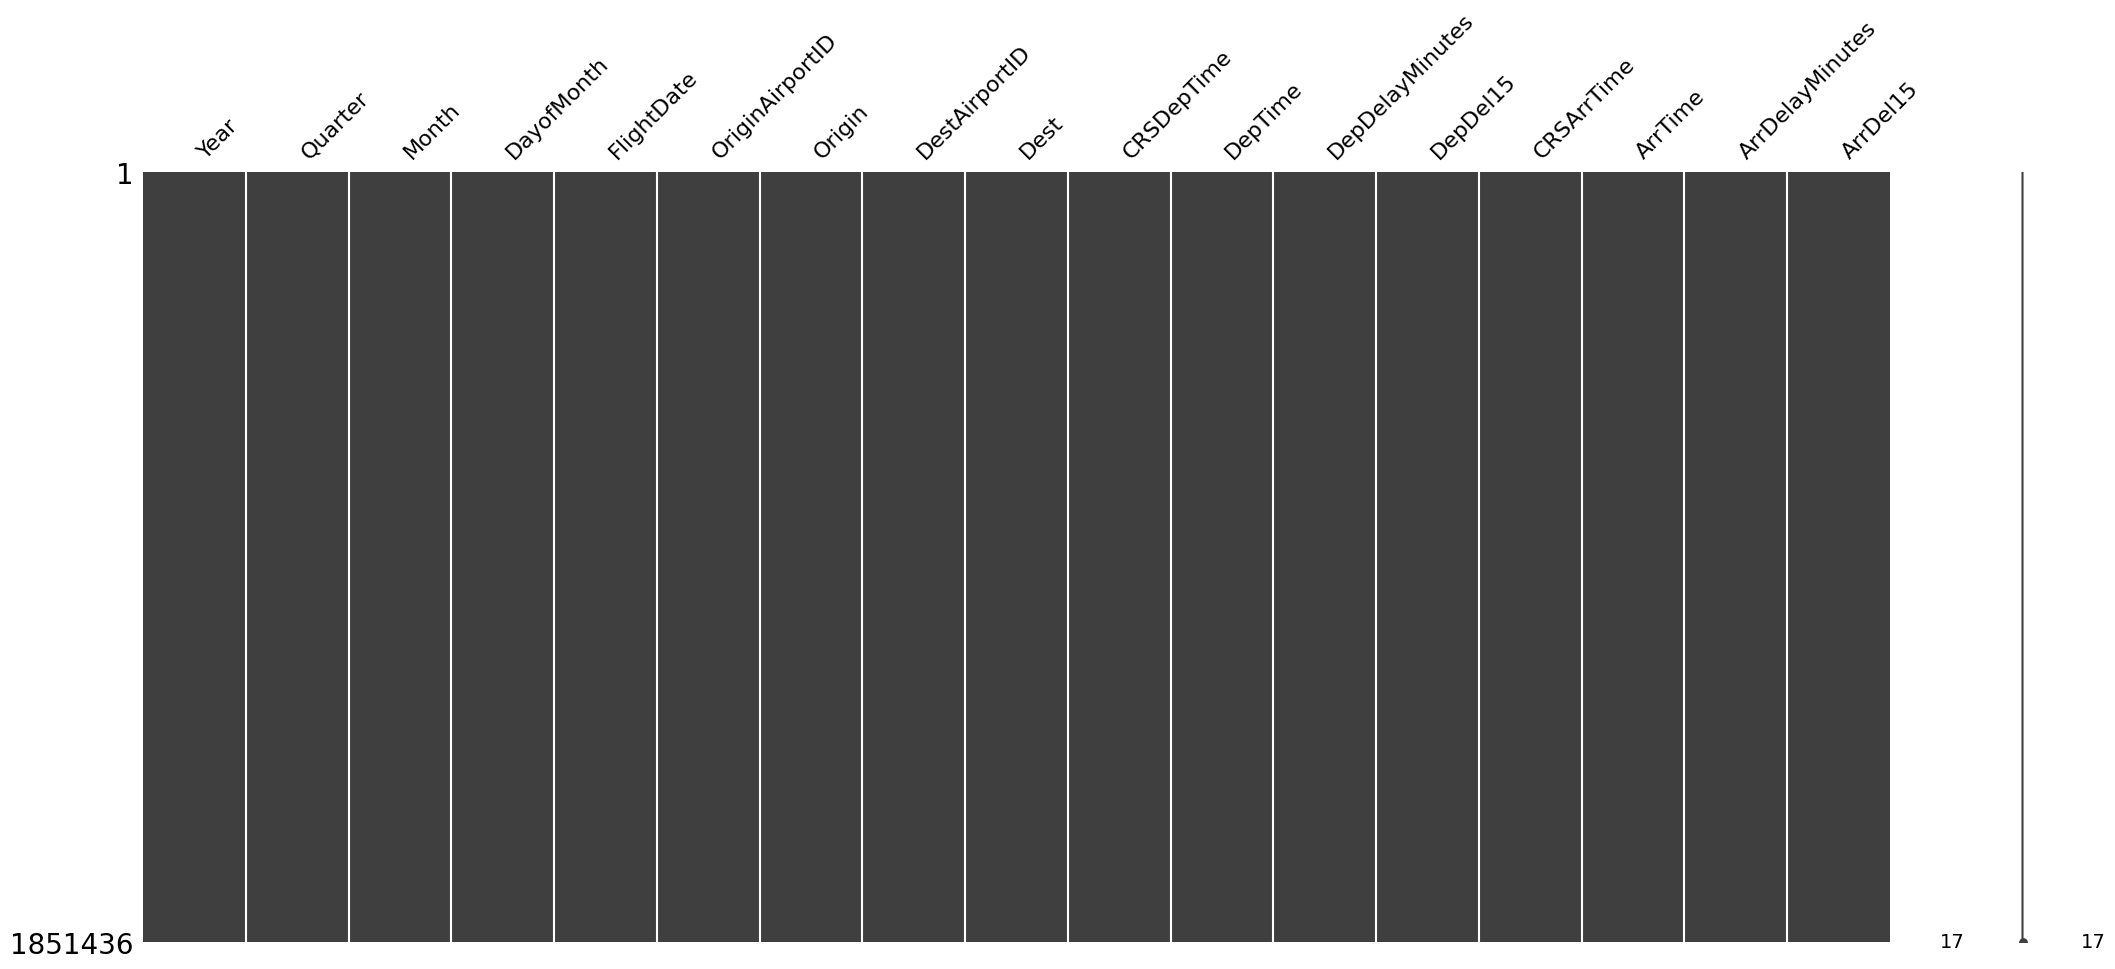

In [8]:
print(msno.matrix(flightdata_df))